In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import statsmodels.api as sm
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
import warnings
warnings.filterwarnings('ignore')
from itertools import combinations
import matplotlib.pyplot as plt
from pykalman import KalmanFilter

In [2]:
tickers = [
    'PETR4', 'VALE3', 'ITUB4', 'PRIO3', 'BBDC4', 'B3SA3', 'AXIA3', 'SBSP3', 
    'BBAS3', 'BPAC11', 'ITSA4', 'RENT3', 'ABEV3', 'WEGE3', 'EQTL3', 'ENEV3', 
    'RDOR3', 'SUZB3', 'LREN3', 'VBBR3', 'RADL3', 'GGBR4', 'BRAV3', 'CSMG3', 
    'TOTS3', 'CMIG4', 'RAIL3', 'CYRE3', 'CSAN3', 'VIVT3', 'UGPA3', 'CURY3', 
    'BBSE3', 'ALOS3', 'HAPV3', 'ENGI11', 'TIMS3', 'USIM5', 'CPFE3', 'MULT3', 
    'KLBN11', 'MBRF3', 'DIRR3', 'MGLU3', 'PSSA3', 'HYPE3', 'CEAB3', 'EGIE3', 
    'TAEE11', 'SANB11'
]

tickers_yfinance = [f"{ticker}.SA" for ticker in tickers]

dados_brutos = yf.download(
    tickers = tickers_yfinance,
    start="2024-07-01",
    end="2025-06-30",
    auto_adjust=True
)

df_fechamento  = dados_brutos['Close'].copy()
df_fechamento  = df_fechamento.ffill()        # ffill no fechamento
df_consolidado = np.log(df_fechamento)        # log em cima do ffill

df_consolidado.columns = [col.replace('.SA', '') for col in df_consolidado.columns]
df_consolidado.index   = df_consolidado.index.strftime('%Y-%m-%d')

print("\n--- Processamento Concluído ---")
print(f"Período : {df_consolidado.index[0]} → {df_consolidado.index[-1]}")
print(f"Matriz  : {df_consolidado.shape[0]} dias x {df_consolidado.shape[1]} ações.")
df_consolidado

[*********************100%***********************]  50 of 50 completed


--- Processamento Concluído ---
Período : 2024-07-01 → 2025-06-27
Matriz  : 248 dias x 50 ações.


,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,...,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
Date,,,,,,,,,,,,,,,,,,,,,
2024-07-01,2.321078,2.899102,3.480842,2.285509,3.157992,2.348532,3.264964,3.384298,3.318959,2.149398,...,4.000758,3.377571,2.618382,3.360987,2.976233,2.063058,3.976787,2.813103,2.998262,3.674972
2024-07-02,2.321951,2.884287,3.499027,2.283597,3.161400,2.346814,3.265269,3.387818,3.327198,2.129980,...,3.999890,3.378444,2.602050,3.340026,2.965597,2.075684,3.973456,2.830494,2.989288,3.676401
2024-07-03,2.314946,2.906664,3.503588,2.281681,3.171182,2.350080,3.269524,3.418638,3.327555,2.174716,...,3.995366,3.383373,2.593144,3.352925,2.982194,2.078191,3.993124,2.865348,2.989727,3.678303
2024-07-04,2.321078,2.934978,3.526091,2.295960,3.176410,2.354146,3.275270,3.434096,3.323624,2.217536,...,3.989419,3.384241,2.608363,3.353600,2.982194,2.098018,3.988126,2.887461,3.003912,3.673064
2024-07-05,2.309659,2.950870,3.519261,2.290273,3.171931,2.365446,3.275572,3.439947,3.347329,2.214538,...,3.949145,3.387991,2.597607,3.347854,2.992656,2.078191,3.984046,2.915903,3.009745,3.680200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-23,2.562186,2.981977,3.621193,2.552097,3.025610,2.719044,3.441724,3.699708,2.982127,2.793947,...,3.924887,3.452025,2.994282,3.715522,2.767057,1.470176,3.837447,2.959090,3.345923,3.682797
2025-06-24,2.558491,3.015321,3.623681,2.566462,3.042069,2.722071,3.438904,3.721137,2.910612,2.820043,...,3.926817,3.453192,2.991457,3.723666,2.792669,1.435084,3.837250,2.971553,3.350910,3.678944
2025-06-25,2.531483,3.011270,3.611429,2.573096,3.033638,2.713571,3.428685,3.714045,2.861822,2.864271,...,3.919850,3.457846,2.973378,3.709734,2.766467,1.391282,3.836062,2.966955,3.327722,3.688071


In [3]:
# Criando a matriz de correlação

matriz_correlacao = df_consolidado.corr()

# Mostra a matriz com um degradê de cores (estilo heatmap)

matriz_correlacao.style.background_gradient(cmap='coolwarm', axis=None).format(precision=2)

,ABEV3,ALOS3,AXIA3,B3SA3,BBAS3,BBDC4,BBSE3,BPAC11,BRAV3,CEAB3,CMIG4,CPFE3,CSAN3,CSMG3,CURY3,CYRE3,DIRR3,EGIE3,ENEV3,ENGI11,EQTL3,GGBR4,HAPV3,HYPE3,ITSA4,ITUB4,KLBN11,LREN3,MBRF3,MGLU3,MULT3,PETR4,PRIO3,PSSA3,RADL3,RAIL3,RDOR3,RENT3,SANB11,SBSP3,SUZB3,TAEE11,TIMS3,TOTS3,UGPA3,USIM5,VALE3,VBBR3,VIVT3,WEGE3
ABEV3,1.00,0.33,0.75,0.71,0.11,0.59,0.63,0.70,-0.48,0.74,0.42,0.79,-0.43,0.32,0.77,0.76,0.79,0.17,0.41,0.49,0.64,-0.44,-0.31,0.09,0.77,0.80,-0.62,0.50,0.74,0.16,0.51,-0.52,-0.48,0.73,-0.58,-0.31,0.61,0.28,0.48,0.80,-0.42,0.81,0.75,0.69,-0.24,-0.42,-0.06,-0.00,0.71,-0.48
ALOS3,0.33,1.00,0.56,0.57,-0.09,0.84,-0.22,0.69,-0.01,0.54,0.17,0.28,0.50,0.29,0.62,0.60,0.44,0.88,0.89,0.89,0.84,-0.10,0.67,0.86,0.71,0.62,-0.46,0.71,-0.04,0.75,0.96,-0.61,0.33,0.12,0.08,0.61,0.76,0.91,0.86,0.37,-0.70,0.66,0.65,0.29,0.65,0.19,0.36,0.83,0.52,-0.28
AXIA3,0.75,0.56,1.00,0.91,0.39,0.65,0.60,0.85,-0.16,0.63,0.16,0.82,-0.21,0.18,0.87,0.89,0.75,0.51,0.68,0.80,0.85,-0.69,0.00,0.46,0.86,0.86,-0.74,0.43,0.44,0.45,0.67,-0.57,-0.22,0.48,-0.46,0.01,0.77,0.42,0.80,0.76,-0.75,0.75,0.87,0.73,0.09,-0.19,-0.00,0.19,0.69,-0.63
B3SA3,0.71,0.57,0.91,1.00,0.21,0.71,0.57,0.91,-0.08,0.71,0.25,0.83,-0.29,0.29,0.88,0.87,0.81,0.45,0.62,0.78,0.84,-0.68,-0.06,0.43,0.90,0.92,-0.66,0.54,0.57,0.34,0.68,-0.51,-0.16,0.61,-0.59,-0.03,0.84,0.40,0.80,0.85,-0.63,0.81,0.88,0.81,-0.02,-0.34,-0.18,0.16,0.75,-0.64
BBAS3,0.11,-0.09,0.39,0.21,1.00,-0.17,0.54,0.08,-0.09,-0.16,-0.09,0.15,-0.15,-0.30,0.15,0.26,0.01,-0.04,0.07,0.07,0.10,-0.38,-0.11,-0.13,0.10,0.08,-0.13,-0.28,-0.11,0.11,-0.04,0.06,-0.37,-0.13,0.08,-0.13,-0.04,-0.22,0.15,0.09,-0.19,0.00,0.04,0.10,0.06,0.19,0.16,-0.25,-0.02,0.03
BBDC4,0.59,0.84,0.65,0.71,-0.17,1.00,0.06,0.82,-0.23,0.74,0.46,0.53,0.13,0.53,0.77,0.72,0.70,0.62,0.82,0.81,0.82,-0.23,0.34,0.65,0.86,0.82,-0.53,0.91,0.35,0.42,0.90,-0.54,0.14,0.52,-0.29,0.21,0.91,0.69,0.86,0.64,-0.56,0.80,0.82,0.53,0.27,-0.26,0.10,0.61,0.81,-0.31
BBSE3,0.63,-0.22,0.60,0.57,0.54,0.06,1.00,0.42,-0.36,0.36,0.25,0.72,-0.81,0.08,0.52,0.56,0.58,-0.31,-0.06,0.08,0.24,-0.68,-0.70,-0.38,0.43,0.51,-0.44,-0.01,0.69,-0.26,-0.02,-0.10,-0.72,0.61,-0.64,-0.62,0.26,-0.35,0.14,0.68,-0.12,0.37,0.44,0.68,-0.58,-0.52,-0.38,-0.57,0.45,-0.33
BPAC11,0.70,0.69,0.85,0.91,0.08,0.82,0.42,1.00,-0.21,0.83,0.36,0.83,-0.21,0.50,0.94,0.92,0.88,0.50,0.70,0.83,0.91,-0.54,0.01,0.49,0.95,0.96,-0.73,0.66,0.54,0.39,0.80,-0.54,-0.12,0.67,-0.58,0.04,0.90,0.52,0.83,0.87,-0.63,0.85,0.94,0.84,0.03,-0.31,-0.08,0.28,0.84,-0.63
BRAV3,-0.48,-0.01,-0.16,-0.08,-0.09,-0.23,-0.36,-0.21,1.00,-0.52,-0.55,-0.35,0.43,-0.36,-0.39,-0.39,-0.50,0.26,-0.15,0.03,-0.12,0.13,0.38,0.31,-0.35,-0.35,0.35,-0.37,-0.43,0.34,-0.16,0.28,0.67,-0.57,0.39,0.53,-0.22,0.05,-0.00,-0.37,0.01,-0.28,-0.30,-0.39,0.39,0.32,-0.10,0.24,-0.51,-0.05
CEAB3,0.74,0.54,0.63,0.71,-0.16,0.74,0.36,0.83,-0.52,1.00,0.48,0.79,-0.36,0.52,0.88,0.84,0.92,0.25,0.54,0.60,0.75,-0.39,-0.20,0.21,0.87,0.89,-0.68,0.73,0.73,0.14,0.67,-0.57,-0.36,0.84,-0.70,-0.21,0.78,0.45,0.57,0.83,-0.39,0.83,0.83,0.85,-0.22,-0.37,-0.06,0.11,0.84,-0.55


In [ ]:
# Cria uma lista para armazenar os resultados
resultados_integracao = []

# Loop para testar cada ação dentro do seu DataFrame consolidado
for coluna in df_consolidado.columns:
    serie_nivel = df_consolidado[coluna].dropna()
    serie_diff = df_consolidado[coluna].diff().dropna()
    
    # 1. Teste de Dickey-Fuller Aumentado (ADF) em NÍVEL
    # Usamos maxlag='AIC' para que o algoritmo escolha o número ideal de lags automaticamente
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    p_valor_nivel = adf_nivel[1]
    
    # 2. Teste ADF na PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    p_valor_diff = adf_diff[1]
    
    # 3. Lógica para determinar a Ordem de Integração
    # Se o p-valor for menor ou igual a 0.05, rejeita-se H0 (a série é estacionária)
    if p_valor_nivel <= 0.05:
        ordem = "I(0) - Estacionária em nível"
    elif p_valor_diff <= 0.05:
        ordem = "I(1) - Integrada de ordem 1"
    else:
        ordem = "I(2) ou superior"
        
    # Guardando os dados na lista
    resultados_integracao.append({
        'Ativo': coluna,
        'p-valor (Nível)': round(p_valor_nivel, 4),
        'Estacionária em Nível?': 'Sim' if p_valor_nivel <= 0.05 else 'Não',
        'p-valor (1ª Dif)': round(p_valor_diff, 4),
        'Estacionária em 1ª Dif?': 'Sim' if p_valor_diff <= 0.05 else 'Não',
        'Ordem de Integração': ordem
    })

# Transformando os resultados em um DataFrame para visualização limpa
df_resultado_final = pd.DataFrame(resultados_integracao)
df_resultado_final

,Ativo,p-valor (Nível),Estacionária em Nível?,p-valor (1ª Dif),Estacionária em 1ª Dif?,Ordem de Integração
0,ABEV3,0.4804,Não,0.0000,Sim,I(1) - Integrada de ordem 1
1,ALOS3,0.6985,Não,0.0000,Sim,I(1) - Integrada de ordem 1
2,AXIA3,0.6795,Não,0.0000,Sim,I(1) - Integrada de ordem 1
3,B3SA3,0.7648,Não,0.0000,Sim,I(1) - Integrada de ordem 1
4,BBAS3,0.2607,Não,0.0000,Sim,I(1) - Integrada de ordem 1
5,BBDC4,0.8748,Não,0.0000,Sim,I(1) - Integrada de ordem 1
6,BBSE3,0.3656,Não,0.0000,Sim,I(1) - Integrada de ordem 1
7,BPAC11,0.8581,Não,0.0000,Sim,I(1) - Integrada de ordem 1
8,BRAV3,0.3756,Não,0.0000,Sim,I(1) - Integrada de ordem 1
9,CEAB3,0.9614,Não,0.0000,Sim,I(1) - Integrada de ordem 1


In [4]:
cesta_definitiva = df_consolidado.drop(columns=['CMIG4'])

resultados_estacionariedade = []

for coluna in cesta_definitiva.columns:
    serie_nivel = cesta_definitiva[coluna].dropna()
    serie_diff = serie_nivel.diff().dropna()
    
    # 1. TESTES EM NÍVEL
    adf_nivel = adfuller(serie_nivel, autolag='AIC')
    kpss_nivel = kpss(serie_nivel, regression='c', nlags="auto")
    
    # 2. TESTES NA PRIMEIRA DIFERENÇA
    adf_diff = adfuller(serie_diff, autolag='AIC')
    kpss_diff = kpss(serie_diff, regression='c', nlags="auto")
    
    # Armazenando os p-valores
    resultados_estacionariedade.append({
        'Ativo': coluna,
        'ADF Nível (p-valor)': round(adf_nivel[1], 4),
        'KPSS Nível (p-valor)': round(kpss_nivel[1], 4),
        'ADF 1ª Dif (p-valor)': round(adf_diff[1], 4),
        'KPSS 1ª Dif (p-valor)': round(kpss_diff[1], 4)
    })

# Convertendo em DataFrame para exibição
df_testes_estatisticos = pd.DataFrame(resultados_estacionariedade)
df_testes_estatisticos

,Ativo,ADF Nível (p-valor),KPSS Nível (p-valor),ADF 1ª Dif (p-valor),KPSS 1ª Dif (p-valor)
0,ABEV3,0.4804,0.0100,0.0000,0.1000
1,ALOS3,0.6985,0.0416,0.0000,0.1000
2,AXIA3,0.6795,0.0100,0.0000,0.1000
3,B3SA3,0.7648,0.0100,0.0000,0.1000
4,BBAS3,0.2607,0.1000,0.0000,0.1000
5,BBDC4,0.8748,0.0749,0.0000,0.1000
6,BBSE3,0.3656,0.0100,0.0000,0.1000
7,BPAC11,0.8581,0.0100,0.0000,0.1000
8,BRAV3,0.3756,0.0100,0.0000,0.1000
9,CEAB3,0.9614,0.0100,0.0000,0.1000


In [5]:
# Usa a cesta_definitiva da célula anterior (já sem as I(0))
# e remove adicionalmente as que falharam no KPSS
colunas_remover = [col for col in ['BBDC4', 'BBSA3', 'CSMG3', 'ENEV3', 'LREN3', 'MULT3', 'PETR4', 'SANB11'] if col in cesta_definitiva.columns]

cesta_johansen = cesta_definitiva.drop(columns=colunas_remover)

ativos         = cesta_johansen.columns
todos_os_pares = list(combinations(ativos, 2))
resultados_pares = []

for at1, at2 in todos_os_pares:
    df_par = cesta_johansen[[at1, at2]].dropna()
    res    = coint_johansen(df_par, det_order=0, k_ar_diff=1)

    traco_r0     = res.lr1[0];  vc_traco  = res.cvt[0, 1]
    eigen_r0     = res.lr2[0];  vc_eigen  = res.cvm[0, 1]

    cointegra_traco = traco_r0 > vc_traco
    cointegra_eigen = eigen_r0 > vc_eigen

    beta_at2 = np.round(res.evec[1, 0] / res.evec[0, 0], 4) \
               if (cointegra_traco or cointegra_eigen) else np.nan

    resultados_pares.append({
        'Ativo 1'              : at1,
        'Ativo 2'              : at2,
        'Estatística Traço'    : np.round(traco_r0, 2),
        'V.C. Traço (95%)'     : np.round(vc_traco,  2),
        'Rejeita r=0 (Traço)?': 'Sim' if cointegra_traco else 'Não',
        'Estatística Max-Eigen': np.round(eigen_r0, 2),
        'V.C. Max-Eigen (95%)' : np.round(vc_eigen,  2),
        'Rejeita r=0 (Eigen)?': 'Sim' if cointegra_eigen else 'Não',
        'Beta (Ativo 2)'       : beta_at2
    })

df_todos_os_pares = pd.DataFrame(resultados_pares)

df_pares_cointegrados = df_todos_os_pares[
    (df_todos_os_pares['Rejeita r=0 (Traço)?'] == 'Sim') |
    (df_todos_os_pares['Rejeita r=0 (Eigen)?'] == 'Sim')
].sort_values('Estatística Traço', ascending=False).reset_index(drop=True)

print(f"Pares cointegrados encontrados: {len(df_pares_cointegrados)}")
print(f"Ativos na cesta do Johansen: {len(cesta_johansen.columns)}")
df_pares_cointegrados

Pares cointegrados encontrados: 57
Ativos na cesta do Johansen: 42


,Ativo 1,Ativo 2,Estatística Traço,V.C. Traço (95%),Rejeita r=0 (Traço)?,Estatística Max-Eigen,V.C. Max-Eigen (95%),Rejeita r=0 (Eigen)?,Beta (Ativo 2)
0,GGBR4,ITSA4,30.20,15.49,Sim,28.07,14.26,Sim,0.6642
1,GGBR4,ITUB4,27.88,15.49,Sim,26.35,14.26,Sim,0.5857
2,HYPE3,VBBR3,23.08,15.49,Sim,20.10,14.26,Sim,-1.3538
3,CURY3,GGBR4,22.50,15.49,Sim,21.06,14.26,Sim,2.6812
4,ITUB4,TIMS3,20.64,15.49,Sim,20.62,14.26,Sim,-0.7944
5,BPAC11,GGBR4,20.63,15.49,Sim,18.57,14.26,Sim,1.9461
6,SBSP3,WEGE3,20.38,15.49,Sim,20.38,14.26,Sim,1.2007
7,ALOS3,BBSE3,20.28,15.49,Sim,18.39,14.26,Sim,0.7371
8,CPFE3,WEGE3,20.03,15.49,Sim,20.01,14.26,Sim,0.8714
9,B3SA3,RDOR3,19.89,15.49,Sim,16.75,14.26,Sim,-1.0691


In [6]:
resultados_meia_vida = []

for _, linha in df_pares_cointegrados.iterrows():
    at1  = linha['Ativo 1']
    at2  = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']

    try:
        spread  = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread  = spread.dropna()

        df_reg  = pd.DataFrame({
            'Y': spread.diff(),
            'X': spread.shift(1)
        }).dropna()

        modelo      = sm.OLS(df_reg['Y'], sm.add_constant(df_reg['X'])).fit()
        lambda_coef = modelo.params['X']

        hl = np.round(-np.log(2) / lambda_coef, 2) if lambda_coef < 0 else 'Divergente'

        resultados_meia_vida.append({
            'Par'                   : f"{at1} x {at2}",
            'Valor do Lambda'       : np.round(lambda_coef, 6),
            'Meia-Vida (Dias Úteis)': hl
        })
    except Exception:
        continue

df_estatistica_pares = pd.DataFrame(resultados_meia_vida)
df_estatistica_pares['_ord'] = pd.to_numeric(
    df_estatistica_pares['Meia-Vida (Dias Úteis)'], errors='coerce')
df_estatistica_pares = (df_estatistica_pares
                        .sort_values('_ord')
                        .drop(columns='_ord')
                        .reset_index(drop=True))

print(f"Meia-vida calculada para {len(df_estatistica_pares)} pares.")
df_estatistica_pares

Meia-vida calculada para 57 pares.


,Par,Valor do Lambda,Meia-Vida (Dias Úteis)
0,EGIE3 x GGBR4,-0.023505,29.49
1,ALOS3 x GGBR4,-0.019267,35.98
2,RDOR3 x TAEE11,-0.018112,38.27
3,GGBR4 x TAEE11,-0.015126,45.83
4,MGLU3 x VBBR3,-0.014676,47.23
5,ENGI11 x GGBR4,-0.013405,51.71
6,BBSE3 x ENGI11,-0.012987,53.37
7,BBSE3 x RENT3,-0.012899,53.74
8,EQTL3 x GGBR4,-0.012531,55.31
9,GGBR4 x RDOR3,-0.012322,56.25


In [ ]:
def calcular_hurst_estavel(serie):
    """
    Calcula o Expoente de Hurst através da abordagem de variância dos lags,
    evitando divisões instáveis em sub-blocos e garantindo limites reais [0, 1].
    """
    serie = np.asarray(serie)
    n = len(serie)
    if n < 100:
        return np.nan
        
    # Define lags seguros (escalas de tempo macro, de 10 dias até um quarto da amostra)
    lags = np.unique(np.logspace(1, np.log10(n // 4), num=15).astype(int))
    
    variancias = []
    for lag in lags:
        # Calcula a diferença da série temporal escalada no lag correspondente
        dif = serie[lag:] - serie[:-lag]
        # Armazena a variância dessa diferença
        variancias.append(np.var(dif))
        
    # Em escalas de tempo financeiras, a Variância do Spread é proporcional a lag^(2H)
    # Logo: log(Variância) = 2H * log(lag) + C
    if len(variancias) < 2:
        return np.nan
        
    coeffs = np.polyfit(np.log(lags), np.log(variancias), 1)
    
    # O coeficiente angular é igual a 2H. Logo, Hurst = Coeffs[0] / 2
    h_estimado = coeffs[0] / 2
    
    # Limitador de segurança econométrica para manter a fronteira teórica [0, 1]
    return np.clip(h_estimado, 0.0001, 0.9999)

# ==============================================================================
# LOOP CORRIGIDO PARA OS PARES
# ==============================================================================
resultados_hurst = []

print(f"Calculando o Expoente de Hurst para {len(df_pares_cointegrados)} pares...")

for indice, linha in df_pares_cointegrados.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    try:
        # Spread: S_t = P1_t - beta * P2_t  
        spread = df_consolidado[at1] - (beta * df_consolidado[at2])
        spread = spread.dropna()
        
        # Calcula o Hurst robusto
        h_score = calcular_hurst_estavel(spread)
        
        resultados_hurst.append({
            'Par': f"{at1} x {at2}",
            'Estatística Traço': linha['Estatística Traço'],
            'Beta': beta,
            'Expoente de Hurst (H)': np.round(h_score, 4)
        })
    except Exception:
        continue

df_pares_hurst = pd.DataFrame(resultados_hurst)

# Ordena do menor Hurst (maior força de reversão) para o maior
df_pares_hurst = df_pares_hurst.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

df_pares_hurst

Calculando o Expoente de Hurst para 57 pares...


,Par,Estatística Traço,Beta,Expoente de Hurst (H)
0,EGIE3 x GGBR4,17.60,5.6827,0.3588
1,ALOS3 x GGBR4,16.55,2.6927,0.3907
2,GGBR4 x SBSP3,19.26,0.6069,0.4068
3,GGBR4 x TAEE11,17.42,2.0852,0.4146
4,SBSP3 x TOTS3,17.61,-0.7111,0.4235
5,RDOR3 x TAEE11,17.32,-3.2355,0.4677
6,CURY3 x GGBR4,22.50,2.6812,0.4700
7,GGBR4 x RDOR3,19.14,0.5317,0.4715
8,BPAC11 x GGBR4,20.63,1.9461,0.4969
9,B3SA3 x RDOR3,19.89,-1.0691,0.5015


In [ ]:
# 1. Cria uma cópia da tabela base do Johansen
df_base = df_pares_cointegrados[['Ativo 1', 'Ativo 2', 'Estatística Traço', 'Estatística Max-Eigen', 'Beta (Ativo 2)']].copy()


df_base['Par'] = df_base['Ativo 1'] + ' x ' + df_base['Ativo 2']

# 2. Isola as colunas de métricas das outras tabelas
df_mv_isolado = df_estatistica_pares[['Par', 'Meia-Vida (Dias Úteis)']]
df_hurst_isolado = df_pares_hurst[['Par', 'Expoente de Hurst (H)']]

# 3. Faz o cruzamento inteligente (PROCV) baseado na coluna 'Par' que agora existe em todas
df_ultimo = pd.merge(df_base, df_mv_isolado, on='Par', how='left')
df_ultimo = pd.merge(df_ultimo, df_hurst_isolado, on='Par', how='left')

# 4. Reorganiza a ordem das colunas para ficar visualmente perfeito para o TCC
df_ultimo = df_ultimo[[
    'Par', 'Ativo 1', 'Ativo 2', 
    'Estatística Traço', 'Estatística Max-Eigen', 
    'Beta (Ativo 2)', 'Meia-Vida (Dias Úteis)', 'Expoente de Hurst (H)'
]]

# 5. Ordena o resultado final pelo menor Expoente de Hurst (H)
df_ultimo = df_ultimo.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

# Exibe a tabela final unificada
df_ultimo

,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,EGIE3 x GGBR4,EGIE3,GGBR4,17.60,15.34,5.6827,29.49,0.3588
1,ALOS3 x GGBR4,ALOS3,GGBR4,16.55,12.46,2.6927,35.98,0.3907
2,GGBR4 x SBSP3,GGBR4,SBSP3,19.26,17.81,0.6069,68.36,0.4068
3,GGBR4 x TAEE11,GGBR4,TAEE11,17.42,14.17,2.0852,45.83,0.4146
4,SBSP3 x TOTS3,SBSP3,TOTS3,17.61,17.12,-0.7111,210.67,0.4235
5,RDOR3 x TAEE11,RDOR3,TAEE11,17.32,15.38,-3.2355,38.27,0.4677
6,CURY3 x GGBR4,CURY3,GGBR4,22.50,21.06,2.6812,76.97,0.4700
7,GGBR4 x RDOR3,GGBR4,RDOR3,19.14,16.30,0.5317,56.25,0.4715
8,BPAC11 x GGBR4,BPAC11,GGBR4,20.63,18.57,1.9461,74.57,0.4969
9,B3SA3 x RDOR3,B3SA3,RDOR3,19.89,16.75,-1.0691,80.13,0.5015


In [9]:
# ==============================================================================
# FILTRAGEM DO GRUPO DE PARES FILTRADOS PARA O BACKTEST 
# ==============================================================================

# 1. Garante que a coluna de Meia-Vida seja lida como número (excluindo os "Divergente")
df_ultimo['Meia-Vida (Dias Úteis)'] = pd.to_numeric(df_ultimo['Meia-Vida (Dias Úteis)'], errors='coerce')

# 2. Aplica-se as três condições simultaneamente:
#    - Estatística Traço > 15.49 (Significância de Johansen)
#    - Meia-Vida < 30 dias úteis (Velocidade comercial de reversão)
#    - Expoente de Hurst < 0.50 (Anticorrelação local confirmada)
condicao_traco = df_ultimo['Estatística Traço'] > 15.49
condicao_mv = df_ultimo['Meia-Vida (Dias Úteis)'] < 30
condicao_hurst = df_ultimo['Expoente de Hurst (H)'] < 0.50
#condicao_beta  = df_ultimo['Beta (Ativo 2)'].abs() <= 10

# 3. Cria-se o DataFrame filtrado com os pares eleitos 
df_pares_selecionados = df_ultimo[condicao_traco & condicao_mv & condicao_hurst].reset_index(drop=True)

# 4. Ordena-se pelo menor Hurst para garantir que os mais eficientes fiquem no topo
df_pares_selecionados = df_pares_selecionados.sort_values(by='Expoente de Hurst (H)', ascending=True).reset_index(drop=True)

print(f"Sucesso! Foram selecionados {len(df_pares_selecionados)} pares que cumprem todos os requisitos rigorosos.")

# Exibe a lista finalizada que irá para o robô de backtest
df_pares_selecionados

Sucesso! Foram selecionados 1 pares que cumprem todos os requisitos rigorosos.


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,EGIE3 x GGBR4,EGIE3,GGBR4,17.6,15.34,5.6827,29.49,0.3588


In [10]:
# 1. Filtra os preços do consolidado para o período de estimação
df_est = df_consolidado.loc['2024-07-01':'2025-06-30'].copy()

# Dicionário simples para guardar as séries
series_pares = {}

# 2. Loop direto que passa apenas pelos pares selecionados do seu df_pares_filtrados
for indice, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    beta = linha['Beta (Ativo 2)']
    
    # 3. Calcula o Spread e o Z-Score
    spread = df_est[at1] - (beta * df_est[at2])
    zscore = (spread - spread.mean()) / spread.std()
    
    # 4. Adiciona direto no dicionário com nomes claros para as colunas
    series_pares[f"{par_nome}_Spread"] = spread
    series_pares[f"{par_nome}_Z-Score"] = zscore

# 5. Transforma no DataFrame final
df_historico_estimacao = pd.DataFrame(series_pares)

# Exibe o resultado final na tela
df_historico_estimacao

,EGIE3 x GGBR4_Spread,EGIE3 x GGBR4_Z-Score
Date,,
2024-07-01,-12.756048,-0.147656
2024-07-02,-12.807941,-0.257566
2024-07-03,-12.747289,-0.129104
2024-07-04,-12.710693,-0.051594
2024-07-05,-12.638073,0.102219
...,...,...
2025-06-23,-12.240206,0.944912
2025-06-24,-12.189577,1.052145
2025-06-25,-12.126299,1.186170


In [11]:
# ── Download do período de trading ───────────────────────────────────────────
tickers_yf = list(set(
    [f"{t}.SA" for t in df_pares_selecionados['Ativo 1'].tolist() +
                        df_pares_selecionados['Ativo 2'].tolist()]
))

dados_trad = yf.download(tickers=tickers_yf, start="2025-07-01",
                          end="2025-12-31", auto_adjust=True, progress=False)

df_trad = np.log(dados_trad['Close'].ffill())
df_trad.columns = [c.replace('.SA', '') for c in df_trad.columns]
df_trad.index   = df_trad.index.strftime('%Y-%m-%d')

# ── Kalman + Spread estático + Z-Score ───────────────────────────────────────
series_trading = {}

for _, linha in df_pares_selecionados.iterrows():
    par_nome = linha['Par']
    at1      = linha['Ativo 1']
    at2      = linha['Ativo 2']
    beta_0   = linha['Beta (Ativo 2)']

    try:
        # ── Parâmetros fixos da estimação ──────────────────────────────────────
        spread_est = df_est[at1] - (beta_0 * df_est[at2])
        media_est  = spread_est.mean()
        desvio_est = spread_est.std()

        # ── Spread e Z-Score do trading com beta ESTÁTICO ─────────────────────
        spread_trad = df_trad[at1] - (beta_0 * df_trad[at2])
        zscore_trad = (spread_trad - media_est) / desvio_est

        # ── Beta dinâmico do Kalman (apenas informativo) ───────────────────────
        y = df_trad[at1].values
        x = df_trad[at2].values

        matriz_obs = np.vstack([x, np.ones(len(x))]).T[:, np.newaxis, :]

        kf = KalmanFilter(
            n_dim_obs=1,
            n_dim_state=2,
            initial_state_mean=np.array([beta_0, 0.0]),
            initial_state_covariance=np.ones((2, 2)),
            transition_matrices=np.eye(2),
            observation_matrices=matriz_obs,
            observation_covariance=1.0,
            transition_covariance=np.eye(2) * 1e-5
        )

        estados, _    = kf.filter(y)
        beta_dinamico = estados[:, 0]

        # ── Verificação de sanidade do Kalman ──────────────────────────────────
        beta_max = np.abs(beta_dinamico).max()
        if beta_max > abs(beta_0) * 10:
            print(f"  [AVISO] {par_nome}: Kalman divergiu — beta máximo = {beta_max:.2f}  "
                  f"(beta Johansen = {beta_0:.4f})")

        # ── Armazena ───────────────────────────────────────────────────────────
        series_trading[f"{par_nome}_Beta_Kalman"] = pd.Series(
            beta_dinamico, index=df_trad.index)
        series_trading[f"{par_nome}_Spread"]      = spread_trad
        series_trading[f"{par_nome}_Z-Score"]     = zscore_trad

    except Exception as e:
        print(f"Erro no par {par_nome}: {e}")
        continue

df_historico_trading = pd.DataFrame(series_trading)

print(f"\nPeriodo de trading: {df_trad.index[0]} → {df_trad.index[-1]}")
print(f"Dias úteis        : {len(df_trad)}")
print(f"Pares processados : {df_historico_trading.shape[1] // 3}")
df_historico_trading


Periodo de trading: 2025-07-01 → 2025-12-30
Dias úteis        : 128
Pares processados : 1


,EGIE3 x GGBR4_Beta_Kalman,EGIE3 x GGBR4_Spread,EGIE3 x GGBR4_Z-Score
Date,,,
2025-07-01,2.660739,-12.102969,1.235583
2025-07-02,2.547702,-12.262305,0.898105
2025-07-03,2.508584,-12.317347,0.781524
2025-07-04,2.485480,-12.366959,0.676445
2025-07-07,2.467562,-12.455991,0.487873
...,...,...,...
2025-12-22,2.345013,-13.712110,-2.172623
2025-12-23,2.343894,-13.735248,-2.221629
2025-12-26,2.342810,-13.730120,-2.210767


In [12]:
DESVIO_ENTRADA = 2.0
DESVIO_SAIDA   = 0.5
STOP_LOSS      = 3.0

resumo_trades = []

for _, linha_par in df_pares_selecionados.iterrows():
    par_nome = linha_par['Par']
    col_z    = f"{par_nome}_Z-Score"

    if col_z not in df_historico_trading.columns:
        continue

    z = df_historico_trading[col_z].dropna()

    estava_comprado = False
    estava_vendido  = False
    total_trades    = 0

    for z_atual in z:
        # ── Posição comprada: abriu quando z <= -2, fecha quando volta a 0 ───
        if estava_comprado:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_comprado = False
                total_trades += 1
            elif z_atual <= -STOP_LOSS:
                estava_comprado = False
                total_trades += 1
        else:
            if z_atual <= -DESVIO_ENTRADA:
                estava_comprado = True

        # ── Posição vendida: abriu quando z >= +2, fecha quando volta a 0 ────
        if estava_vendido:
            if -DESVIO_SAIDA <= z_atual <= DESVIO_SAIDA:
                estava_vendido = False
                total_trades += 1
            elif z_atual >= STOP_LOSS:
                estava_vendido = False
                total_trades += 1
        else:
            if z_atual >= DESVIO_ENTRADA:
                estava_vendido = True

    resumo_trades.append({
        'Par'                 : par_nome,
        'Hurst'               : linha_par['Expoente de Hurst (H)'],
        'Meia-Vida'           : linha_par['Meia-Vida (Dias Úteis)'],
        'Quantidade de Trades': total_trades,
    })

df_analise_operacoes = (pd.DataFrame(resumo_trades)
                        .sort_values('Quantidade de Trades', ascending=False)
                        .reset_index(drop=True))

print(f"Varredura concluída! {len(df_analise_operacoes)} pares analisados.")
df_analise_operacoes

Varredura concluída! 1 pares analisados.


,Par,Hurst,Meia-Vida,Quantidade de Trades
0,EGIE3 x GGBR4,0.3588,29.49,0


In [13]:
print(f"{'Par':30s}  {'média':>7}  {'min':>7}  {'max':>7}  {'status':>10}")
print("─" * 70)

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    
    if col_z not in df_historico_trading.columns:
        print(f"{par:30s}  ── sem dados ──")
        continue
        
    z      = df_historico_trading[col_z]
    media  = z.mean()
    status = "✓ OK" if abs(media) <= 1.5 else "✗ DIVERGIU"
    
    print(f"{par:30s}  {media:>7.2f}  {z.min():>7.2f}  {z.max():>7.2f}  {status:>10}")

Par                               média      min      max      status
──────────────────────────────────────────────────────────────────────
EGIE3 x GGBR4                     -0.27    -2.23     1.24        ✓ OK


In [14]:
# ── Filtro 1: apenas pares com média do z-score próxima de zero ───────────────
LIMITE_MEDIA = 1.5

pares_validos   = []
pares_excluidos = []

for _, linha in df_pares_selecionados.iterrows():
    par   = linha['Par']
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z     = df_historico_trading[col_z]
    media = z.mean()
    if abs(media) <= LIMITE_MEDIA:
        pares_validos.append(linha)
    else:
        pares_excluidos.append((par, round(media, 2)))

df_pares_validos = pd.DataFrame(pares_validos).reset_index(drop=True)

print(f"Pares válidos   : {len(df_pares_validos)}")
print(f"Pares excluídos : {len(pares_excluidos)}")
if pares_excluidos:
    print("\nExcluídos por divergência do spread:")
    for par, media in pares_excluidos:
        print(f"  {par:30s}  média z-score = {media:.2f}")

df_pares_validos

Pares válidos   : 1
Pares excluídos : 0


,Par,Ativo 1,Ativo 2,Estatística Traço,Estatística Max-Eigen,Beta (Ativo 2),Meia-Vida (Dias Úteis),Expoente de Hurst (H)
0,EGIE3 x GGBR4,EGIE3,GGBR4,17.6,15.34,5.6827,29.49,0.3588


In [15]:
MAX_POR_ATIVO = 2
contagem        = {}
pares_limitados = []

for _, linha in df_pares_validos.iterrows():
    at1 = linha['Ativo 1']
    at2 = linha['Ativo 2']
    c1  = contagem.get(at1, 0)
    c2  = contagem.get(at2, 0)

    if c1 < MAX_POR_ATIVO and c2 < MAX_POR_ATIVO:
        pares_limitados.append(linha)
        contagem[at1] = c1 + 1
        contagem[at2] = c2 + 1
    else:
        print(f"  [LIMITADO] {linha['Par']}")

df_pares_validos = pd.DataFrame(pares_limitados).reset_index(drop=True)
print(f"\nPares após limite: {len(df_pares_validos)}")


Pares após limite: 1


═══ Estatísticas da Estratégia ══════════════════════════════════
Pares operados            : 1
Retorno acumulado líquido : -2.65%
Retorno médio anualizado  : -4.38%
Volatilidade anualizada   : 13.78%
Sharpe anualizado         : -0.3178
Maximum Drawdown          : -8.71%

Retorno acumulado por par:
EGIE3 x GGBR4   -2.65

Pares lucrativos: 0
Pares com perda : 1


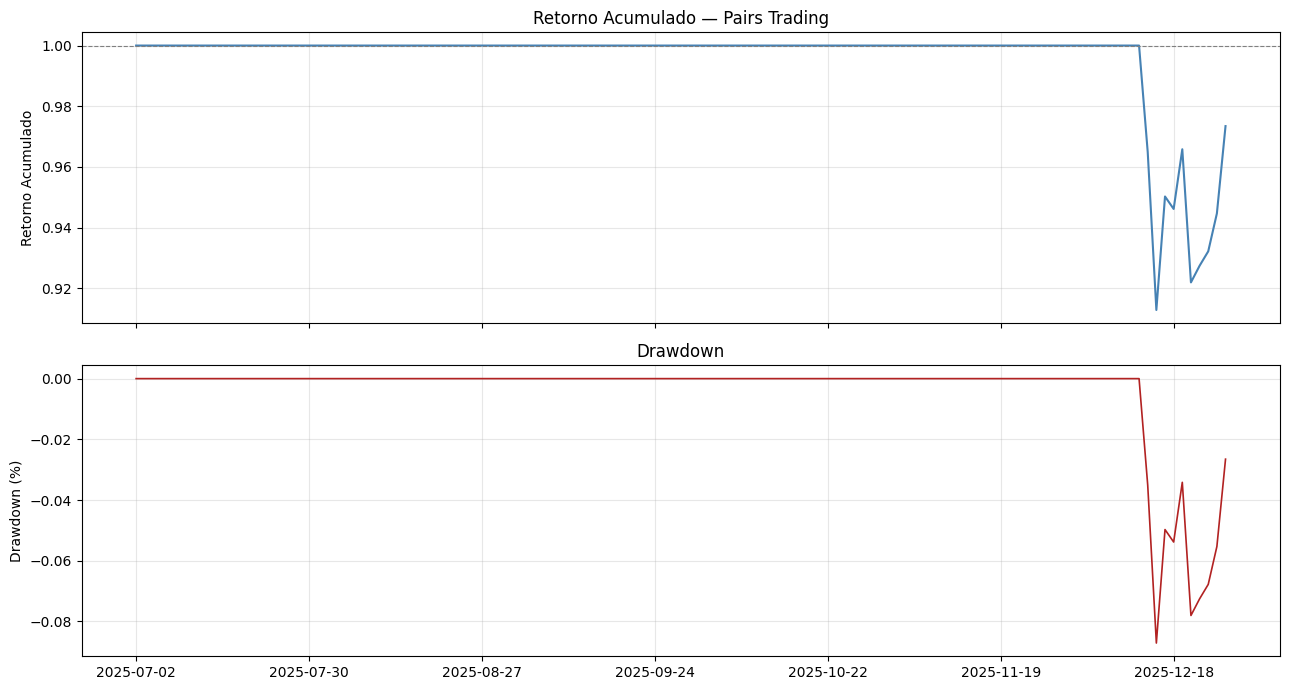

In [16]:
# ── Parâmetros da estratégia ──────────────────────────────────────────────────
ENTRADA   = 2.0
SAIDA     = 0.5
STOP_LOSS = 3.0
CUSTO     = 0.001

# ── Backtest ──────────────────────────────────────────────────────────────────
retornos_diarios = {}

for _, linha in df_pares_validos.iterrows():
    par_nome  = linha['Par']
    at1       = linha['Ativo 1']
    at2       = linha['Ativo 2']
    meia_vida = int(np.ceil(linha['Meia-Vida (Dias Úteis)']))

    col_z    = f"{par_nome}_Z-Score"
    col_beta = f"{par_nome}_Beta_Kalman"

    z    = df_historico_trading[col_z]
    beta = df_historico_trading[col_beta]
    p1   = df_trad[at1]
    p2   = df_trad[at2]

    posicao         = 0
    dias_em_posicao = 0
    retornos_par    = []
    datas           = []

    for i in range(1, len(z)):
        data      = z.index[i]
        z_hoje    = z.iloc[i]
        beta_hoje = beta.iloc[i]

        ret1 = p1.iloc[i] - p1.iloc[i - 1]
        ret2 = p2.iloc[i] - p2.iloc[i - 1]

        # ── Atualiza posição PRIMEIRO ─────────────────────────────────────────
        nova_posicao = posicao

        if posicao == 0:
            if z_hoje >= ENTRADA:
                nova_posicao    = -1
                dias_em_posicao = 0
            elif z_hoje <= -ENTRADA:
                nova_posicao    = +1
                dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje <= -STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo
            elif posicao == -1:
                if -SAIDA <= z_hoje <= SAIDA:
                    nova_posicao = 0   # saída normal
                elif z_hoje >= STOP_LOSS:
                    nova_posicao = 0   # stop loss
                elif dias_em_posicao >= meia_vida:
                    nova_posicao = 0   # prazo máximo

        if nova_posicao != posicao:
            dias_em_posicao = 0

        custo_dia = CUSTO if nova_posicao != posicao else 0.0
        posicao   = nova_posicao

        # ── Calcula retorno DEPOIS de atualizar posição ───────────────────────
        retorno_bruto   = posicao * (ret1 - beta_hoje * ret2)
        retorno_liquido = retorno_bruto - custo_dia

        retornos_par.append(retorno_liquido)
        datas.append(data)

    retornos_diarios[par_nome] = pd.Series(retornos_par, index=datas)

df_retornos = pd.DataFrame(retornos_diarios).fillna(0)

# ── Retorno da carteira com pesos iguais ──────────────────────────────────────
retorno_carteira  = df_retornos.mean(axis=1)
retorno_acumulado = (1 + retorno_carteira).cumprod()
pico              = retorno_acumulado.cummax()
drawdown          = (retorno_acumulado - pico) / pico
mdd               = drawdown.min()
sharpe            = (retorno_carteira.mean() / retorno_carteira.std()) * np.sqrt(252)

# ── Estatísticas ──────────────────────────────────────────────────────────────
print(f"═══ Estatísticas da Estratégia ══════════════════════════════════")
print(f"Pares operados            : {len(df_pares_validos)}")
print(f"Retorno acumulado líquido : {(retorno_acumulado.iloc[-1] - 1) * 100:.2f}%")
print(f"Retorno médio anualizado  : {retorno_carteira.mean() * 252 * 100:.2f}%")
print(f"Volatilidade anualizada   : {retorno_carteira.std() * np.sqrt(252) * 100:.2f}%")
print(f"Sharpe anualizado         : {sharpe:.4f}")
print(f"Maximum Drawdown          : {mdd * 100:.2f}%")

# ── Retorno por par ───────────────────────────────────────────────────────────
retorno_por_par = (1 + df_retornos).prod() - 1
retorno_por_par = retorno_por_par.sort_values()
print(f"\nRetorno acumulado por par:")
print((retorno_por_par * 100).round(2).to_string())
print(f"\nPares lucrativos: {(retorno_por_par > 0).sum()}")
print(f"Pares com perda : {(retorno_por_par < 0).sum()}")

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

retorno_acumulado.plot(ax=axes[0], color='steelblue', linewidth=1.5)
axes[0].set_title('Retorno Acumulado — Pairs Trading')
axes[0].set_ylabel('Retorno Acumulado')
axes[0].axhline(1, color='gray', linestyle='--', linewidth=0.8)
axes[0].grid(True, alpha=0.3)

drawdown.plot(ax=axes[1], color='firebrick', linewidth=1.2)
axes[1].set_title('Drawdown')
axes[1].set_ylabel('Drawdown (%)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [53]:
# ── Exportação dos resultados do Período para Excel ───────────────────────────
ARQUIVO = "periodo_7_jul2024_dez2025.xlsx"

# ── Número total de trades ────────────────────────────────────────────────────
total_trades = 0
for par in df_pares_validos['Par']:
    col_z = f"{par}_Z-Score"
    if col_z not in df_historico_trading.columns:
        continue
    z = df_historico_trading[col_z]
    posicao = 0
    dias_em_posicao = 0
    meia_vida_par = int(np.ceil(
        df_pares_validos.loc[df_pares_validos['Par'] == par, 'Meia-Vida (Dias Úteis)'].values[0]
    ))
    for z_atual in z:
        nova_posicao = posicao
        if posicao == 0:
            if z_atual >= ENTRADA:
                nova_posicao = -1; dias_em_posicao = 0
            elif z_atual <= -ENTRADA:
                nova_posicao = +1; dias_em_posicao = 0
        else:
            dias_em_posicao += 1
            if posicao == +1:
                if -SAIDA <= z_atual <= SAIDA or z_atual <= -STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
            elif posicao == -1:
                if -SAIDA <= z_atual <= SAIDA or z_atual >= STOP_LOSS or dias_em_posicao >= meia_vida_par:
                    nova_posicao = 0
        if nova_posicao == 0 and posicao != 0:
            total_trades += 1
            dias_em_posicao = 0
        posicao = nova_posicao

# ── Aba 5: Estatísticas resumidas ─────────────────────────────────────────────
df_estatisticas = pd.DataFrame([{
    'Período de Estimação'       : 'Jul/2021 – Jun/2022',
    'Período de Trading'         : 'Jul/2022 – Dez/2022',
    'Pares Operados'             : len(df_pares_validos),
    'Total de Trades'            : total_trades,
    'Retorno Acumulado (%)'      : round((retorno_acumulado.iloc[-1] - 1) * 100, 2),
    'Retorno Anualizado (%)'     : round(retorno_carteira.mean() * 252 * 100, 2),
    'Volatilidade Anualizada (%)': round(retorno_carteira.std() * np.sqrt(252) * 100, 2),
    'Sharpe Anualizado'          : round(sharpe, 4),
    'Maximum Drawdown (%)'       : round(mdd * 100, 2),
}])

# ── Aba 4: Retorno diário da carteira + acumulado ─────────────────────────────
df_retorno_carteira = pd.DataFrame({
    'Retorno Diário'    : retorno_carteira,
    'Retorno Acumulado' : retorno_acumulado,
    'Drawdown'          : drawdown,
})

# ── Corrige zeros negativos nos retornos por par ──────────────────────────────
df_retornos_limpo = df_retornos.round(8)

# ── Exporta para Excel com múltiplas abas ─────────────────────────────────────
with pd.ExcelWriter(ARQUIVO, engine='openpyxl') as writer:

    # Aba 1 — Pares selecionados
    df_pares_validos.to_excel(
        writer, sheet_name='1_Pares_Selecionados', index=False)

    # Aba 2 — Z-scores do período de trading
    df_historico_trading[
        [c for c in df_historico_trading.columns if '_Z-Score' in c]
    ].to_excel(writer, sheet_name='2_ZScores_Trading')

    # Aba 3 — Retornos diários por par (sem zeros negativos)
    df_retornos_limpo.to_excel(writer, sheet_name='3_Retornos_Por_Par')

    # Aba 4 — Retorno da carteira
    df_retorno_carteira.to_excel(writer, sheet_name='4_Retorno_Carteira')

    # Aba 5 — Estatísticas resumidas
    df_estatisticas.to_excel(
        writer, sheet_name='5_Estatisticas', index=False)

print(f"Arquivo '{ARQUIVO}' salvo com sucesso!")
print(f"\nAbas geradas:")
print(f"  1_Pares_Selecionados : {len(df_pares_validos)} pares")
print(f"  2_ZScores_Trading    : {len([c for c in df_historico_trading.columns if '_Z-Score' in c])} séries")
print(f"  3_Retornos_Por_Par   : {df_retornos_limpo.shape[1]} pares × {df_retornos_limpo.shape[0]} dias")
print(f"  4_Retorno_Carteira   : {len(df_retorno_carteira)} dias")
print(f"  5_Estatisticas       : {total_trades} trades no período")

Arquivo 'periodo_7_jul2024_dez2025.xlsx' salvo com sucesso!

Abas geradas:
  1_Pares_Selecionados : 1 pares
  2_ZScores_Trading    : 1 séries
  3_Retornos_Por_Par   : 1 pares × 127 dias
  4_Retorno_Carteira   : 127 dias
  5_Estatisticas       : 0 trades no período


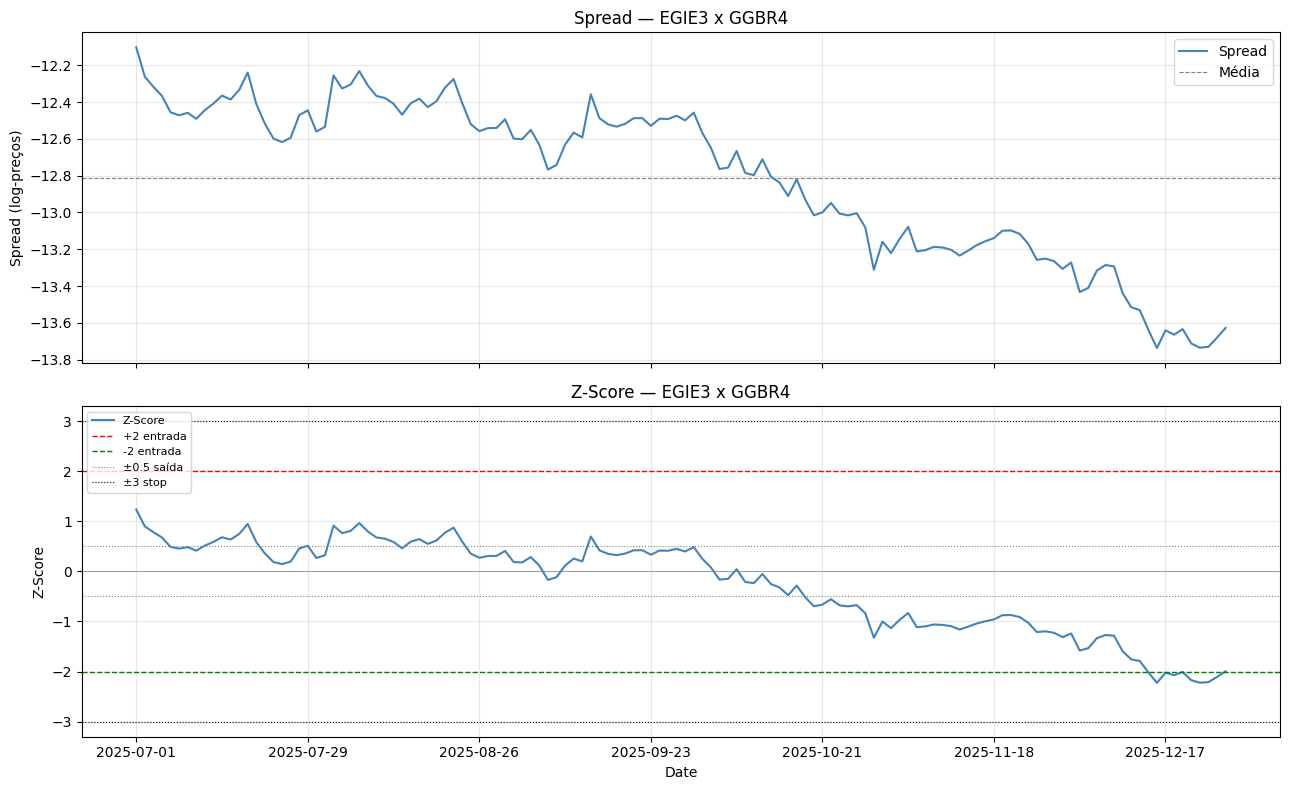

In [57]:
par    = 'EGIE3 x GGBR4'

z      = df_historico_trading[f'{par}_Z-Score']
spread = df_historico_trading[f'{par}_Spread']

# ── Gráfico ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

# Painel 1 — Spread
spread.plot(ax=axes[0], color='steelblue', linewidth=1.5, label='Spread')
axes[0].axhline(spread.mean(), color='gray', linestyle='--',
                linewidth=0.8, label='Média')
axes[0].set_title(f'Spread — {par}')
axes[0].set_ylabel('Spread (log-preços)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Painel 2 — Z-Score
z.plot(ax=axes[1], color='steelblue', linewidth=1.5, label='Z-Score')

# Linhas de referência
axes[1].axhline( 2.0, color='red',   linestyle='--', linewidth=1,   label='+2 entrada')
axes[1].axhline(-2.0, color='green', linestyle='--', linewidth=1,   label='-2 entrada')
axes[1].axhline( 0.5, color='gray',  linestyle=':',  linewidth=0.8, label='±0.5 saída')
axes[1].axhline(-0.5, color='gray',  linestyle=':',  linewidth=0.8)
axes[1].axhline( 3.0, color='black', linestyle=':',  linewidth=0.8, label='±3 stop')
axes[1].axhline(-3.0, color='black', linestyle=':',  linewidth=0.8)
axes[1].axhline( 0.0, color='gray',  linestyle='-',  linewidth=0.5)

axes[1].set_title(f'Z-Score — {par}')
axes[1].set_ylabel('Z-Score')
axes[1].legend(loc='upper left', fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'spread_{par.replace(" x ", "_")}.png', dpi=150, bbox_inches='tight')
plt.show()